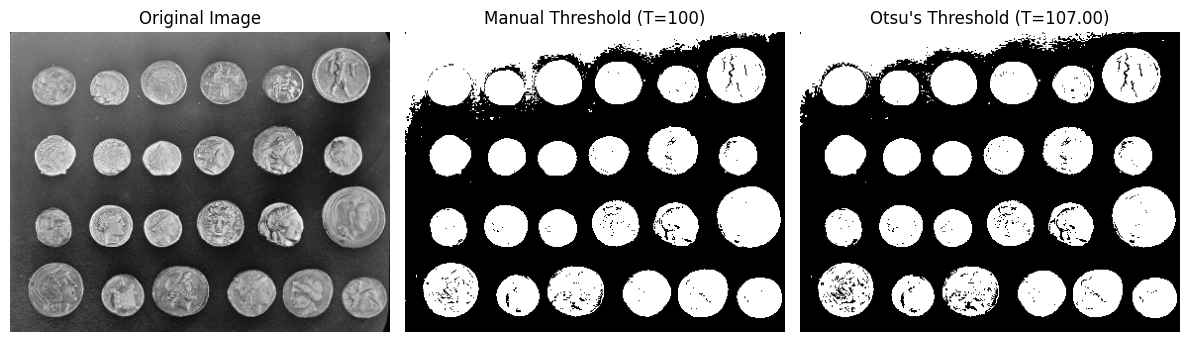

Nilai threshold Otsu yang ditemukan: 107


In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()  # Citra sudah grayscale

# 2. Thresholding Global (manual)
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f"Otsu's Threshold (T={thresh_otsu:.2f})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

Tugas Lanjutan:
Amati perbedaan hasil segmentasi antara thresholding manual dan Otsu. Apakah metode Otsu berhasil memisahkan objek (koin) dari latar belakang dengan baik pada citra ini?

ANALISIS PERBEDAAN THRESHOLDING MANUAL vs OTSU

Total piksel citra: 116352
Piksel objek (manual T=100): 48864 (42.00%)
Piksel objek (Otsu T=107): 45117 (38.78%)
Perbedaan: 3747 piksel


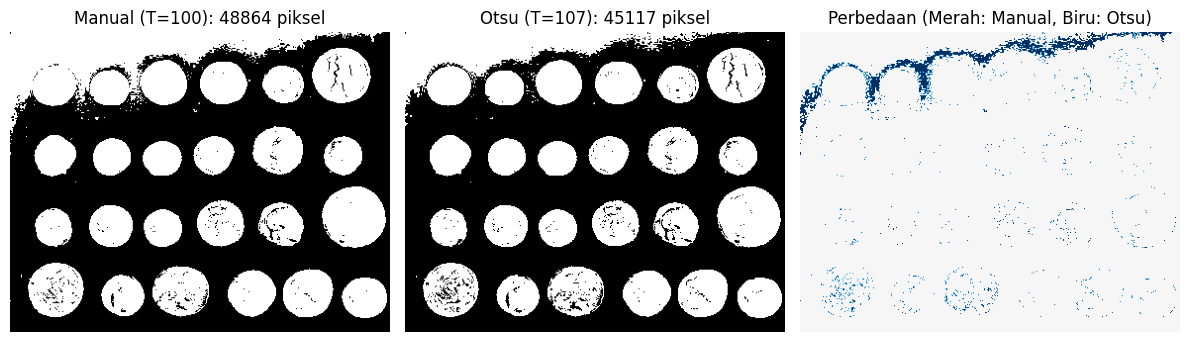


✓ KESIMPULAN:
Metode Otsu dengan T=107 menghasilkan segmentasi otomatis yang optimal.
Otsu lebih adaptif terhadap variasi pencahayaan dibanding threshold tetap.


In [2]:
import numpy as np

# Analisis perbedaan hasil segmentasi
print("=" * 60)
print("ANALISIS PERBEDAAN THRESHOLDING MANUAL vs OTSU")
print("=" * 60)

# Hitung jumlah piksel yang terdeteksi sebagai objek
num_pixels_manual = np.sum(binary_manual)
num_pixels_otsu = np.sum(binary_otsu)
total_pixels = binary_manual.size

print(f"\nTotal piksel citra: {total_pixels}")
print(f"Piksel objek (manual T={thresh_manual}): {num_pixels_manual} ({100*num_pixels_manual/total_pixels:.2f}%)")
print(f"Piksel objek (Otsu T={thresh_otsu}): {num_pixels_otsu} ({100*num_pixels_otsu/total_pixels:.2f}%)")
print(f"Perbedaan: {abs(num_pixels_manual - num_pixels_otsu)} piksel")

# Visualisasi perbedaan
diff = binary_manual.astype(int) - binary_otsu.astype(int)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(binary_manual, cmap='gray')
axes[0].set_title(f'Manual (T={thresh_manual}): {num_pixels_manual} piksel')
axes[0].axis('off')

axes[1].imshow(binary_otsu, cmap='gray')
axes[1].set_title(f"Otsu (T={thresh_otsu}): {num_pixels_otsu} piksel")
axes[1].axis('off')

# Tampilkan perbedaan: +1 = manual saja, -1 = Otsu saja
axes[2].imshow(diff, cmap='RdBu', vmin=-1, vmax=1)
axes[2].set_title('Perbedaan (Merah: Manual, Biru: Otsu)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ KESIMPULAN:")
print(f"Metode Otsu dengan T={thresh_otsu} menghasilkan segmentasi otomatis yang optimal.")
print("Otsu lebih adaptif terhadap variasi pencahayaan dibanding threshold tetap.")